In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ritwikb3/heart-disease-cleveland")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-cleveland' dataset.
Path to dataset files: /kaggle/input/heart-disease-cleveland


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
import os

# 데이터 불러오기 및 확인
df = pd.read_csv(os.path.join(path, "/kaggle/input/heart-disease-cleveland/Heart_disease_cleveland_new.csv"))
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [4]:
# df의 정보 확인
print(df.shape)
df.info()

(303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df["target"].value_counts()

,count
target,
0,164
1,139


In [6]:
df["target"].value_counts()

,count
target,
0,164
1,139


이번 프로젝트에서는 K-means 알고리즘을 확인해볼 예정이기 때문에 target(정답) 컬럼은 사용하지 않았습니다

In [7]:
df_num = df.select_dtypes(include=[np.number]).copy()

X = df_num.drop(columns=["target"])
print(X.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   0       145   233    1        2      150      0      2.3      2   
1   67    1   3       160   286    0        2      108      1      1.5      1   
2   67    1   3       120   229    0        2      129      1      2.6      1   
3   37    1   2       130   250    0        0      187      0      3.5      2   
4   41    0   1       130   204    0        2      172      0      1.4      0   

   ca  thal  
0   0     2  
1   3     1  
2   2     3  
3   0     1  
4   0     1  


In [8]:
X.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')

현재 column의 개수는 13개로 매우 많은 상황이기 때문에 시각화와 해석을 쉽게 하기 위해 대표적인 두 수치(나이, 콜레스트롤)만 사용했습니다

In [9]:
X_simple = X[["age", "chol"]]
X_simple.head()

,age,chol
0,63,233
1,67,286
2,67,229
3,37,250
4,41,204


In [10]:
X_simple.describe()

,age,chol
count,303.000000,303.000000
mean,54.438944,246.693069
std,9.038662,51.776918
min,29.000000,126.000000
25%,48.000000,211.000000
50%,56.000000,241.000000
75%,61.000000,275.000000
max,77.000000,564.000000


K-mean은 거리 기반 알고리즘 입니다. 현재 age는 수십 단위, choi(콜래스트롤)은 수백 단위이므로 변수 간 크기 차이를 맞추기 위해 표준화를 적용했습니다

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_simple)

처음에는 단순하게 환자가 2그룹으로 나뉘는지 확인하기 위해 k = 2로 설정하였습니다

In [12]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

clusters[:10]

array([1, 1, 1, 0, 0, 1, 1, 1, 1, 0], dtype=int32)

In [13]:
df_result = X_simple.copy()
df_result["cluster"] = clusters

df_result.head()

,age,chol,cluster
0,63,233,1
1,67,286,1
2,67,229,1
3,37,250,0
4,41,204,0


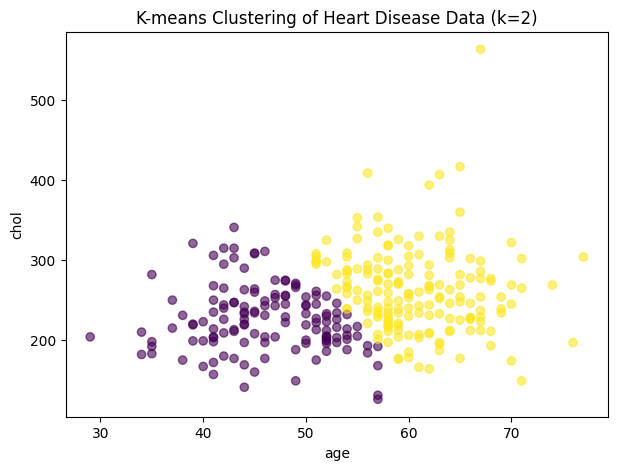

In [14]:
plt.figure(figsize=(7,5))
plt.scatter(
    df_result["age"],
    df_result["chol"],
    c=df_result["cluster"],
    alpha=0.6
)
plt.xlabel("age")
plt.ylabel("chol")
plt.title("K-means Clustering of Heart Disease Data (k=2)")
plt.show()


In [15]:
df_result.groupby("cluster").mean()


,age,chol
cluster,,
0,46.198473,225.748092
1,60.715116,262.645349


In [16]:
# centroid (표준화된 상태)
centroids_scaled = kmeans.cluster_centers_

# 원래 스케일(age, chol)로 복원
centroids = scaler.inverse_transform(centroids_scaled)

centroids


array([[ 46.19847328, 225.7480916 ],
       [ 60.71511628, 262.64534884]])

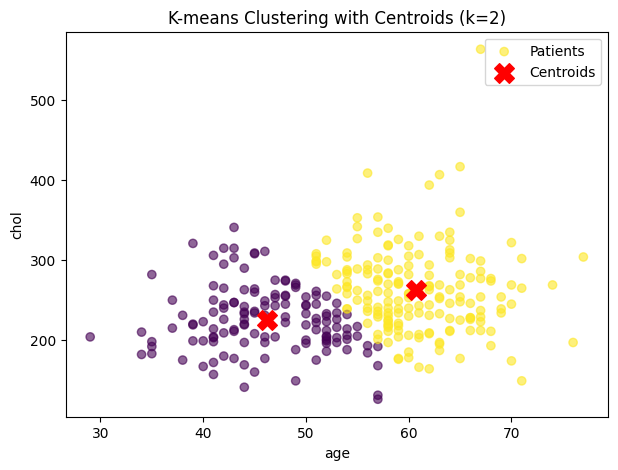

In [17]:
plt.figure(figsize=(7,5))

# 환자 점들
plt.scatter(
    df_result["age"],
    df_result["chol"],
    c=df_result["cluster"],
    alpha=0.6,
    label="Patients"
)

# centroid 점들 (빨간 X)
plt.scatter(
    centroids[:, 0],  # age
    centroids[:, 1],  # chol
    c="red",
    s=200,
    marker="X",
    label="Centroids"
)

plt.xlabel("age")
plt.ylabel("chol")
plt.title("K-means Clustering with Centroids (k=2)")
plt.legend()
plt.show()
